# 🔧 NASA Turbofan RUL — Analyse Exploratoire des Données

> Dataset C-MAPSS (Commercial Modular Aero-Propulsion System Simulation) — NASA Ames Research Center, 2008

## 📋 Sommaire

1. [Imports & Configuration](#1-imports--configuration)
2. [Chargement des données](#data-loading)
3. [Analyse fondamentale](#fundamental-analysis)
4. [Analyse des variables](#variables-analysis)
5. [Analyse univariée](#univariate-analysis)
6. [Analyse multivariée](#6-analyse-multivariee)
7. [Tests statistiques](#7-tests-statistiques)
8. [Conclusions](#8-conclusions)

## 1. Imports & Configuration <a id="1-imports--configuration"></a>

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## 2. Chargement des données <a id="data-loading"></a>

In [43]:
col_names = ["unit_number", "time_cycles", "setting_1", "setting_2", "setting_3"]
col_names += [f'sensor_{i}' for i in range(1, 22)]

df_train = pd.read_csv("../data/CMaps/train_FD001.txt", sep=r"\s+", header=None, names=col_names, index_col=False)
df_test = pd.read_csv("../data/CMaps/test_FD001.txt", sep=r"\s+", header=None, names=col_names, index_col=False)

df_train.head()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 3. Analyse fondamentale <a id="fundamental-analysis"></a>

### Description du dataset

**Quoi :**
Le dataset C-MAPSS simule le comportement de turboréacteurs jusqu'à leur défaillance.
Chaque sous-ensemble (FD001 à FD004) combine des scénarios distincts de conditions opérationnelles et de modes de défaillance.

**Quand & Qui :**
Produit en 2008 par l'équipe de pronostic du NASA Ames Research Center (A. Saxena & K. Goebel).
Utilisé comme référence mondiale lors du PHM 2008 Data Challenge.

**Comment :**
Les données proviennent d'un simulateur haute fidélité — pas de vrais vols.
Un bruit de mesure réaliste est ajouté pour complexifier la prédiction.

**Pourquoi :**
Estimer la RUL (Remaining Useful Life) — combien de cycles reste-t-il avant la panne.
L'enjeu : passer d'une maintenance **préventive** (on change trop tôt par sécurité, coût élevé) à une maintenance **prédictive** (on change juste avant la panne, coût optimisé et sécurité maximale).

### Structure du dataset
Vérifions les dimensions, types et valeurs manquantes.

In [44]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sensor_15    20

**Observations :**
- 20 631 lignes × 26 colonnes
- 4 colonnes entières, 22 flottantes

In [45]:
df_train.isna().sum()

unit_number    0
time_cycles    0
setting_1      0
setting_2      0
setting_3      0
sensor_1       0
sensor_2       0
sensor_3       0
sensor_4       0
sensor_5       0
sensor_6       0
sensor_7       0
sensor_8       0
sensor_9       0
sensor_10      0
sensor_11      0
sensor_12      0
sensor_13      0
sensor_14      0
sensor_15      0
sensor_16      0
sensor_17      0
sensor_18      0
sensor_19      0
sensor_20      0
sensor_21      0
dtype: int64

**Observations :**
- Aucune valeur manquante
- Le dataset est complet et prêt pour l'analyse

In [46]:
df_train.describe()

,unit_number,time_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


**Observations :**
- Les capteurs ont des échelles très différentes — une **normalisation sera nécessaire** avant la modélisation
- Certains capteurs ont un écart-type très faible et d'autres sont statiques → potentiellement peu informatifs
- `time_cycles` va de 1 à 362 — c'est le compteur de cycles, le maximum correspond au moteur ayant la durée de vie la plus longue

In [47]:
duree_vie = df_train.groupby('unit_number')['time_cycles'].max()
duree_vie.describe().round(2)

count    100.00
mean     206.31
std       46.34
min      128.00
25%      177.00
50%      199.00
75%      229.25
max      362.00
Name: time_cycles, dtype: float64

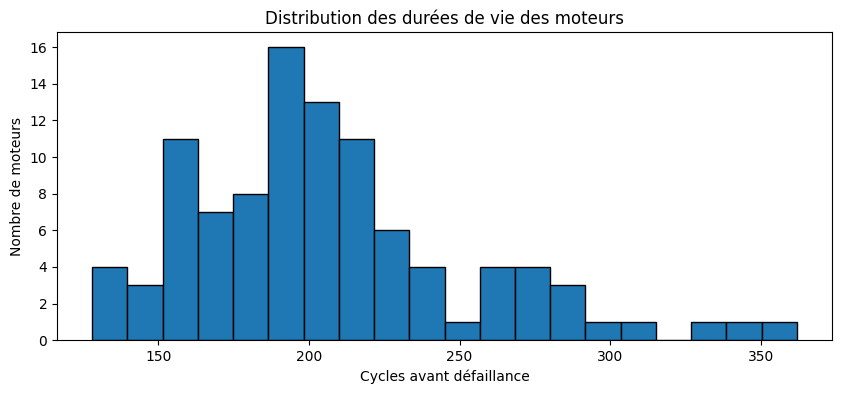

In [48]:
plt.figure(figsize=(10, 4))
plt.hist(duree_vie, bins=20, edgecolor='black')
plt.title("Distribution des durées de vie des moteurs")
plt.xlabel("Cycles avant défaillance")
plt.ylabel("Nombre de moteurs")
plt.show()

**Observations :**
- **100 moteurs** avec des durées de vie variables
- Durée de vie **moyenne** : 206 cycles
- Durée de vie **min** : 128 cycles, **max** : 362 cycles
- **Écart-type** : 46 cycles — variabilité significative entre les moteurs
- La médiane (199) est légèrement inférieure à la moyenne (206) → distribution **asymétrique à droite**
- Quelques moteurs ont une durée de vie exceptionnellement longue (queue vers la droite)

## 4. Analyse des variables <a id="variables-analysis"></a>

 ### Identifier les variables inutiles


In [49]:
df_train.nunique().sort_values(ascending=True)

sensor_1          1
setting_3         1
sensor_10         1
sensor_5          1
sensor_19         1
sensor_16         1
sensor_18         1
sensor_6          2
sensor_17        13
setting_2        13
sensor_8         53
sensor_13        56
unit_number     100
sensor_20       120
setting_1       158
sensor_11       159
sensor_2        310
time_cycles     362
sensor_12       427
sensor_7        513
sensor_15      1918
sensor_3       3012
sensor_4       4051
sensor_21      4745
sensor_14      6078
sensor_9       6403
dtype: int64

**Observations :**
- **7 variables statiques** supprimées : `sensor_1`, `sensor_5`, `sensor_10`, `sensor_16`, `sensor_18`, `sensor_19`, `setting_3` → variance nulle
- `sensor_6` → 2 valeurs uniquement — à évaluer en analyse multivariée
- `setting_2` → 13 paliers fixes — comportement discret malgré le type float
- Le nombre de valeurs uniques seul ne suffit pas à juger l'utilité d'un capteur — la corrélation avec la RUL sera déterminante

In [50]:
capteurs_inutiles = ["sensor_1", "sensor_5", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
settings_inutiles = ["setting_3"]

In [51]:
df_train = df_train.drop(capteurs_inutiles + settings_inutiles, axis=1)

### Classification discrète / continue

| Variable | Type | Analyse |
|---|---|---|
| `unit_number` | Identifiant (Qualitative Nominale) | Aucune - ID moteur |
| `time_cycles` | Quantitative Discrète (362 valeurs) | Continue |
| `setting_2` | Quantitative Discrète (13 valeurs) | Discrète |
| `setting_1` | Quantitative Discrète (158 valeurs) | Continue |
| `sensors` (14 variables) | Quantitative Continue | Continue |

### Créer la variable cible RUL

In [52]:
df_train["engine_rul"] = df_train.groupby("unit_number")["time_cycles"].transform("max") - df_train["time_cycles"]

df_train[["unit_number", "engine_rul"]].head(10)

,unit_number,engine_rul
0,1,191
1,1,190
2,1,189
3,1,188
4,1,187
5,1,186
6,1,185
7,1,184
8,1,183
9,1,182


## 5. Analyse Univariée <a id="univariate-analysis"></a>

### 5.1 Analyse de la variable cible "engine_rul"

In [53]:
df_train["engine_rul"].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: engine_rul, dtype: float64

**Observations :**
- La RUL moyenne sur l'ensemble des observations est de **108 cycles**
- La médiane (103) est proche de la moyenne (108) → distribution **relativement symétrique**
- L'écart-type de 69 cycles indique une **forte variabilité** de la RUL
- RUL min = 0 → des moteurs en fin de vie sont bien présents dans le dataset
- RUL max = 361 → correspond au moteur avec la durée de vie la plus longue au cycle 1
- 50% des observations ont une RUL entre 51 et 155 cycles

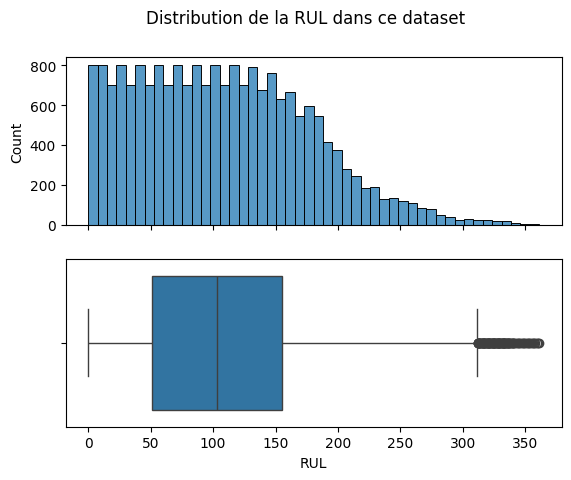

In [54]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
sns.histplot(data=df_train, x="engine_rul", ax=ax[0])
sns.boxplot(data=df_train, x="engine_rul", ax=ax[1])
plt.xlabel("RUL")
plt.suptitle("Distribution de la RUL dans ce dataset")
plt.show()

**Observations :**
- La distribution montre une **forte densité pour les RUL < 150 cycles** (La majorité des moteurs contribuent aux observations dans cette zone)
- Au-delà de 150 cycles, la densité diminue et seuls les moteurs à longue durée de vie contribuent
- **Clipper la RUL à 150 cycles** permettra de rééquilibrer le dataset et de se concentrer sur la zone de RUL qui nous intéresse d'avantage. Cette valeur sera validée lors de la modélisation en comparant les performances avec d'autres valeurs de clipping.

In [69]:
df_train["engine_rul_clipped"] = df_train["engine_rul"].clip(lower=None, upper=150)

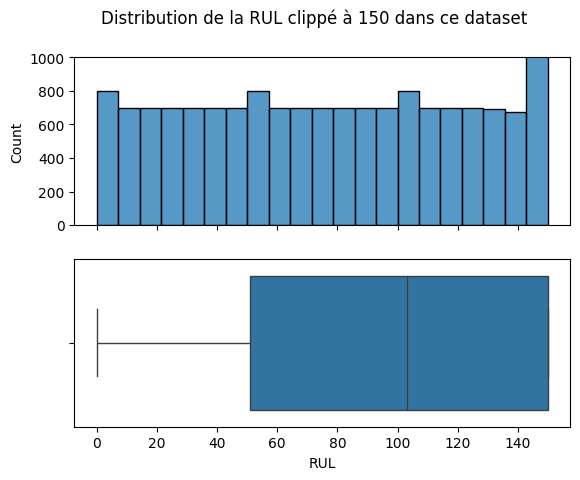

In [80]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True)
sns.histplot(data=df_train, x="engine_rul_clipped", ax=ax[0])
sns.boxplot(data=df_train, x="engine_rul_clipped", ax=ax[1])
plt.xlabel("RUL")
ax[0].set_ylim(top=1000)
plt.suptitle("Distribution de la RUL clippé à 150 dans ce dataset")
plt.show()